# Séries Temporais de m = n + i*k

In [1]:
import pandas as pd
import numpy as np
from scipy.special import jv, yv
from scipy.integrate import trapz
import warnings
from datetime import timedelta
import matplotlib.pyplot as plt
from shapely.geometry import LineString

In [2]:
from datetime import datetime
estacoes= [['primavera',"2017-09-22 00:00:00","2017-12-20 00:00:00"] ]

start_primavera= "2017-09-01 00:00:00"
start_primavera = datetime.strptime(start_primavera, "%Y-%m-%d %H:%M:%S")

end_primavera= "2017-11-30 23:59:59"
end_primavera = datetime.strptime(end_primavera , "%Y-%m-%d %H:%M:%S")


start_verao = "2017-12-01 00:00:00"
start_verao = datetime.strptime(start_verao, "%Y-%m-%d %H:%M:%S")

end_verao = "2018-02-28 23:59:59"
end_verao = datetime.strptime(end_verao, "%Y-%m-%d %H:%M:%S")


start_outono = "2018-03-01 00:00:00"
start_outono = datetime.strptime(start_outono, "%Y-%m-%d %H:%M:%S")

end_outono= "2018-05-30 23:59:59"
end_outono = datetime.strptime(end_outono, "%Y-%m-%d %H:%M:%S")


start_inverno = "2017-06-25 00:00:00"
start_inverno = datetime.strptime(start_inverno, "%Y-%m-%d %H:%M:%S")

end_inverno = "2017-08-31 23:59:59"
end_inverno = datetime.strptime(end_inverno, "%Y-%m-%d %H:%M:%S")

### Funções da biblioteca

In [3]:
def coerceDType(d):
  if type(d) is not np.ndarray:
    return np.array(d)
  else:
    return d
def Mie_ab(m,x):
#  http://pymiescatt.readthedocs.io/en/latest/forward.html#Mie_ab
  mx = m*x
  nmax = np.round(2+x+4*(x**(1/3)))
  nmx = np.round(max(nmax,np.abs(mx))+16)
  n = np.arange(1,nmax+1) #
  nu = n + 0.5 #

  sx = np.sqrt(0.5*np.pi*x)

  px = sx*jv(nu,x) #
  p1x = np.append(np.sin(x), px[0:int(nmax)-1]) #

  chx = -sx*yv(nu,x) #
  ch1x = np.append(np.cos(x), chx[0:int(nmax)-1]) #
  
  gsx = px-(0+1j)*chx #
  gs1x = p1x-(0+1j)*ch1x #

  # B&H Equation 4.89
  Dn = np.zeros(int(nmx),dtype=complex)
  for i in range(int(nmx)-1,1,-1):
    Dn[i-1] = (i/mx)-(1/(Dn[i]+i/mx))

  D = Dn[1:int(nmax)+1] # Dn(mx), drop terms beyond nMax
  da = D/m+n/x
  db = m*D+n/x

  an = (da*px-p1x)/(da*gsx-gs1x)
  bn = (db*px-p1x)/(db*gsx-gs1x)

  return an, bn
def MieQ(m, wavelength, diameter, nMedium=1.0, asDict=False, asCrossSection=False):
#  http://pymiescatt.readthedocs.io/en/latest/forward.html#MieQ
  nMedium = nMedium.real
  m /= nMedium
  wavelength /= nMedium
  x = np.pi*diameter/wavelength
  if x==0:
    return 0, 0, 0, 1.5, 0, 0, 0
  elif x<=0.05:
    return RayleighMieQ(m, wavelength, diameter, nMedium, asDict)
  elif x>0.05:
    nmax = np.round(2+x+4*(x**(1/3)))
    n = np.arange(1,nmax+1)
    n1 = 2*n+1
    n2 = n*(n+2)/(n+1)
    n3 = n1/(n*(n+1))
    x2 = x**2

    an,bn = Mie_ab(m,x)

    qext = (2/x2)*np.sum(n1*(an.real+bn.real))
    qsca = (2/x2)*np.sum(n1*(an.real**2+an.imag**2+bn.real**2+bn.imag**2))
    qabs = qext-qsca

    g1 = [an.real[1:int(nmax)],
          an.imag[1:int(nmax)],
          bn.real[1:int(nmax)],
          bn.imag[1:int(nmax)]]
    g1 = [np.append(x, 0.0) for x in g1]
    g = (4/(qsca*x2))*np.sum((n2*(an.real*g1[0]+an.imag*g1[1]+bn.real*g1[2]+bn.imag*g1[3]))+(n3*(an.real*bn.real+an.imag*bn.imag)))

    qpr = qext-qsca*g
    qback = (1/x2)*(np.abs(np.sum(n1*((-1)**n)*(an-bn)))**2)
    qratio = qback/qsca
    if asCrossSection:
      css = np.pi*(diameter/2)**2
      cext = css*qext
      csca = css*qsca
      cabs = css*qabs
      cpr = css*qpr
      cback = css*qback
      cratio = css*qratio
      if asDict:
        return dict(Cext=cext,Csca=csca,Cabs=cabs,g=g,Cpr=cpr,Cback=cback,Cratio=cratio)
      else:
        return cext, csca, cabs, g, cpr, cback, cratio
    else:
      if asDict:
        return dict(Qext=qext,Qsca=qsca,Qabs=qabs,g=g,Qpr=qpr,Qback=qback,Qratio=qratio)
      else:
        return qext, qsca, qabs, g, qpr, qback, qratio
      
def RayleighMieQ(m, wavelength, diameter, nMedium=1.0, asDict=False, asCrossSection=False):
#  http://pymiescatt.readthedocs.io/en/latest/forward.html#RayleighMieQ
  nMedium = nMedium.real
  m /= nMedium
  wavelength /= nMedium
  x = np.pi*diameter/wavelength
  if x==0:
    return 0, 0, 0, 1.5, 0, 0, 0
  elif x>0:
    LL = (m**2-1)/(m**2+2) # Lorentz-Lorenz term
    LLabsSq = np.abs(LL)**2
    qsca = 8*LLabsSq*(x**4)/3 # B&H eq 5.8
    qabs=4*x*LL.imag # B&H eq. 5.11
    qext=qsca+qabs
    qback = 1.5*qsca # B&H eq. 5.9
    qratio = 1.5
    g = 0
    qpr = qext
    if asCrossSection:
      css = np.pi*(diameter/2)**2
      cext = css*qext
      csca = css*qsca
      cabs = css*qabs
      cpr = css*qpr
      cback = css*qback
      cratio = css*qratio
      if asDict:
        return dict(Cext=cext,Csca=csca,Cabs=cabs,g=g,Cpr=cpr,Cback=cback,Cratio=cratio)
      else:
        return cext, csca, cabs, g, cpr, cback, cratio
    else:
      if asDict:
        return dict(Qext=qext,Qsca=qsca,Qabs=qabs,g=g,Qpr=qpr,Qback=qback,Qratio=qratio)
      else:
        return qext, qsca, qabs, g, qpr, qback, qratio
      
def AutoMieQ(m, wavelength, diameter, nMedium=1.0, crossover=0.01, asDict=False, asCrossSection=False):
#  http://pymiescatt.readthedocs.io/en/latest/forward.html#AutoMieQ
  nMedium = nMedium.real
  m_eff = m / nMedium
  wavelength_eff = wavelength / nMedium
  x_eff = np.pi*diameter/wavelength_eff
  if x_eff==0:
    return 0, 0, 0, 1.5, 0, 0, 0
  elif x_eff<crossover:
    return RayleighMieQ(m, wavelength, diameter, nMedium, asDict=asDict, asCrossSection=asCrossSection)
  else:
    return MieQ(m, wavelength, diameter, nMedium, asDict=asDict, asCrossSection=asCrossSection)      
  
def Mie_SD(m, wavelength, dp, ndp, nMedium=1.0, SMPS=True, interpolate=False, asDict=False):
#  http://pymiescatt.readthedocs.io/en/latest/forward.html#Mie_SD
  nMedium = nMedium.real
  m /= nMedium
  wavelength /= nMedium
  dp = coerceDType(dp)
  ndp = coerceDType(ndp)
  _length = np.size(dp)
  Q_ext = np.zeros(_length)
  Q_sca = np.zeros(_length)
  Q_abs = np.zeros(_length)
  Q_pr = np.zeros(_length)
  Q_back = np.zeros(_length)
  Q_ratio = np.zeros(_length)
  g = np.zeros(_length)
  
  # scaling of 1e-6 to cast in units of inverse megameters - see docs
  aSDn = np.pi*((dp/2)**2)*ndp*(1e-6)
#  _logdp = np.log10(dp)

  for i in range(_length):
    Q_ext[i], Q_sca[i], Q_abs[i], g[i], Q_pr[i], Q_back[i], Q_ratio[i] = AutoMieQ(m,wavelength,dp[i],nMedium)

  if SMPS:
    Bext = np.sum(Q_ext*aSDn)
    Bsca = np.sum(Q_sca*aSDn)
    Babs = Bext-Bsca
    Bback = np.sum(Q_back*aSDn)
    Bratio = np.sum(Q_ratio*aSDn)
    bigG = np.sum(g*Q_sca*aSDn)/np.sum(Q_sca*aSDn)
    Bpr = Bext - bigG*Bsca
  else:
    Bext = trapz(Q_ext*aSDn,dp)
    Bsca = trapz(Q_sca*aSDn,dp)
    Babs = Bext-Bsca
    Bback = trapz(Q_back*aSDn,dp)
    Bratio = trapz(Q_ratio*aSDn,dp)
    bigG = trapz(g*Q_sca*aSDn,dp)/trapz(Q_sca*aSDn,dp)
    Bpr = Bext - bigG*Bsca

  if asDict:
    return dict(Bext=Bext, Bsca=Bsca, Babs=Babs, G=bigG, Bpr=Bpr, Bback=Bback, Bratio=Bratio)
  else:
    return Bext, Bsca, Babs, bigG, Bpr, Bback, Bratio


### Função para calcular os Q para cada intervalo do SMPS

In [4]:
def Q_smps(m, wavelength, dp, nMedium=1.0, SMPS=True, interpolate=False):
  nMedium = nMedium.real
  m /= nMedium
  wavelength /= nMedium
  dp = coerceDType(dp)
  _length = np.size(dp)
  Q_sca = np.zeros(_length)
  Q_abs = np.zeros(_length)

  for i in range(_length):
    resultado = AutoMieQ(m,wavelength,dp[i],nMedium,asDict=True)
    Q_sca[i] = resultado['Qsca']
    Q_abs[i] = resultado['Qabs']
  return {'Qsca': Q_sca, 'Qabs': Q_abs} 

### Arquivos

In [5]:
# Leitura dos dados
smps = pd.read_csv('data/campinas/Campinas-2017_SMPS_TSI_3082_Level3_30min.csv', header=1,sep=';')

smps = smps[smps[' Total concentration Mean (cm-3)']!= ' NaN']#remove linhas com valores nulos na coluna
smps = smps.drop(' ', axis=1)
smps = smps.reset_index()

time= pd.to_datetime(smps[' UnixTime(UTC)'],unit='s')
smps = smps.drop('Time(UTC)', axis=1)
smps['Time(UTC)'] = time
# Definindo a coluna de nefe e hora como índice
smps.set_index('Time(UTC)', inplace=True)

for column in smps.columns:
    smps['%s'%(column)] = smps['%s'%(column)].astype(float)

smps = smps.fillna(0)

smps.index = smps.index - timedelta(hours=3)
smps.index.name = 'Time(UTC) - 3'

In [6]:
# "Desnormalizando" a distribuição
sizeDistributionDiameterBins = smps.columns[5:-2].tolist() #exclui as 5 primeiras colunas e as duas ultimas
sizeDistributionDiameterBins = [float(x) for x in sizeDistributionDiameterBins]

listasDlogs = []
for i in range(len(sizeDistributionDiameterBins) - 1):
    dlogi = np.log(sizeDistributionDiameterBins[i+1]) - np.log(sizeDistributionDiameterBins[i])
    listasDlogs.append(dlogi)

dlog = np.mean(listasDlogs) #media dos dlogs(Dp) da distribuição

In [7]:
nefe = pd.read_csv('data/campinas/Campinas-2017_Nephelometer_Aurora_Ecotech_3000_Level3_5min.csv', sep='; ', header=1)

nefe = nefe[nefe['scat450 Mean (Mm-1)']!= ' NaN']#remove linhas com valores nulos na coluna
nefe = nefe[nefe['scat525 Mean (Mm-1)']!= ' NaN']#remove linhas com valores nulos na coluna
nefe = nefe[nefe['scat635 Mean (Mm-1)']!= ' NaN']#remove linhas com valores nulos na coluna  
nefe = nefe.dropna()
nefe = nefe.reset_index()

time= pd.to_datetime(nefe['UnixTime(UTC)'],unit='s')
nefe = nefe.drop('Time(UTC)', axis=1)
nefe['Time(UTC)'] = time
# Definindo a coluna de nefe e hora como índice
nefe.set_index('Time(UTC)', inplace=True)

for column in nefe.columns:
    nefe['%s'%(column)] = nefe['%s'%(column)].astype(float)

#nefe = nefe[nefe['scat525 Mean (Mm-1)'] <= 900]#remove linhas com valores nulos na coluna
nefe.index = nefe.index - timedelta(hours=3)
nefe.index.name = 'Time(UTC) - 3'

/tmp/ipykernel_16322/2343954547.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  nefe = pd.read_csv('data/campinas/Campinas-2017_Nephelometer_Aurora_Ecotech_3000_Level3_5min.csv', sep='; ', header=1)


In [8]:
#Interpolação e SAE
# Separando os valores para o gráfico
orange = nefe['scat635 Mean (Mm-1)']
green = nefe['scat525 Mean (Mm-1)']
blue = nefe['scat450 Mean (Mm-1)']

nefe['scat637 Mean (Mm-1)'] = np.nan
nefe['SAE'] = np.nan
nefe['sigma_SAE'] = np.nan

lambdas = [635,525,450]
for i in range(len(nefe)):
    sigma = [orange[i],green[i],blue[i]]
    coeff, cov_matrix = np.polyfit(np.log(lambdas),np.log(sigma), 1,cov= True)
    nefe.at[nefe.index[i], 'SAE'] = -coeff[0]
    sigmaSAE = np.sqrt(cov_matrix[0, 0])
    scat637i = np.exp(coeff[0]*np.log(637) + coeff[1])
    nefe.at[nefe.index[i], 'scat637 Mean (Mm-1)'] = scat637i
    nefe.at[nefe.index[i], 'sigma_SAE'] = sigmaSAE

In [9]:
maap = pd.read_csv('data/campinas/Campinas-2017_MAAP_5012_Level3_5min.csv', encoding='latin-1',header=1,sep=';')
maap = maap.dropna(subset=[' Abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna

time= pd.to_datetime(maap[' UnixTime(UTC)'],unit='s')
maap = maap.drop('Time(UTC)', axis=1)
maap['Time(UTC)'] = time
maap.set_index('Time(UTC)', inplace=True)

for column in maap.columns:
   maap['%s'%(column)] = maap['%s'%(column)].astype(float)
maap = maap[maap[' Abs637 Mean (Mm-1)'] >=0]


maap = maap.dropna(subset=[' Abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna
maap = maap.drop(' ',axis=1)
maap.index = maap.index - timedelta(hours=3)
maap.index.name = 'Time(UTC) - 3'

In [10]:
aet = pd.read_csv('data/campinas/Campinas_Aethalometer_AE33_Level2_5min.csv', encoding='latin-1',header=1,sep=';')
aet = aet.dropna(subset=[' abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna

time= pd.to_datetime(aet[' UnixTime(UTC)'],unit='s')
aet = aet.drop('Time(UTC)', axis=1)
aet['Time(UTC)'] = time
aet.set_index('Time(UTC)', inplace=True)

for column in aet.columns:
   aet['%s'%(column)] = aet['%s'%(column)].astype(float)
#aet = aet[aet[' abs637 Mean (Mm-1)'] >=0]


aet = aet.dropna(subset=[' abs637 Mean (Mm-1)'])#remove linhas com valores nulos na coluna
aet = aet.drop(' ',axis=1)
aet.index = aet.index - timedelta(hours=3)
aet.index.name = 'Time(UTC) - 3'

### Intersecções

In [11]:
nefe_30_min = nefe.resample('30min').mean().dropna()
maap_30_min= maap.resample('30min').mean().dropna()
smps_30_min  = smps.resample('30min').mean().dropna()


indices_comuns = smps_30_min.index.intersection(maap_30_min.index)
indices_comuns = indices_comuns.intersection(nefe_30_min.index)
smps_intersec = smps_30_min.loc[indices_comuns]
maap_intersec  = maap_30_min.loc[indices_comuns]
nefe_intersec  = nefe_30_min.loc[indices_comuns]

print(len(indices_comuns))

#smps_media_total = smps_intersec.mean()
#nefe_media_total = nefe_intersec.mean()
#aet_media_total = aet_intersec.mean()
#maap_media_total = maap_intersec.mean()

6485


### Série Temporal

In [12]:
def metodoInversoCampinas(
    n_values = None,
    k_values = None,
    wavelength=None,
    smps_media_total=None,
    smps=None,
    nefe_media_total=None,
    maap_media_total=None,
    Qscat_results =  None,
    Qabs_results = None,
    dlog=None,
    show_3d_plots=False,
    show_contour_plot=False,
    find_intersections=True):
    """
    Função completa para análise Mie e visualização dos resultados.
    """
    sizeDistributionDiameterBins = smps.columns[5:-2].tolist()
    sizeDistribution = smps_media_total.values[5:-2] * dlog
    sizeDistributionDiameterBins = np.array([float(x) for x in sizeDistributionDiameterBins])
    
    Bscat_results = np.empty_like(n_grid, dtype=object)
    Babs_results = np.empty_like(n_grid, dtype=object)
    for i in range(len(n_values)):
        for j in range(len(k_values)):
            # Armazena os arrays completos
            Bscat_results[i, j] = np.sum(Qscat_results[i, j]*sizeDistribution*np.pi*((sizeDistributionDiameterBins/2)**2)*(1e-6))
            Babs_results[i, j]  = np.sum(Qabs_results[i, j]*sizeDistribution*np.pi*((sizeDistributionDiameterBins/2)**2)*(1e-6))       
    
    # 4. Níveis para curvas de nível
    level_scatt = nefe_media_total.iloc[7]
    level_abs = maap_media_total.iloc[2]
    
    # 5. Visualização 3D (opcional)
    if show_3d_plots:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), subplot_kw={'projection': '3d'})
        
        for ax, data, title, ang_azim, level in zip(
            [ax1, ax2], 
            [Bscat_results, Babs_results], 
            [r'$B_{scatt}$', r'$B_{abs}$'],
            [120, 200], 
            [level_scatt, level_abs]
        ):
            surf = ax.plot_surface(n_grid, k_grid, data, edgecolor='none', alpha=0.5)
            offset = np.min(data) - 0.1 * (np.max(data) - np.min(data))
            ax.contour(n_grid, k_grid, data, zdir='z', offset=offset, 
                       linewidths=2.0, linestyles='solid', levels=[level])
            
            ax.view_init(elev=30, azim=ang_azim)
            ax.set_xlabel('n', fontsize=16)
            ax.set_ylabel('k', fontsize=16)
            ax.set_zlabel(title, fontsize=20)
            ax.set_title(rf'$\lambda$ = {wavelength} nm', fontsize=14)
        
        plt.tight_layout()
        plt.show()
    
    # 6. Visualização de contorno 2D (opcional)
    if show_contour_plot:
        # Plota apenas se solicitado
        #plt.figure(figsize=(10, 8))
        cs1_plot = plt.contour(n_grid, k_grid, Bscat_results, levels=[level_scatt],
                            colors='red', linewidths=2.0, linestyles='solid')
        cs2_plot = plt.contour(n_grid, k_grid, Babs_results, levels=[level_abs],
                            colors='blue', linewidths=2.0, linestyles='solid')
        plt.clabel(cs1_plot, fontsize=12, fmt='%.3f', inline=True)
        plt.clabel(cs2_plot, fontsize=12, fmt='%.3f', inline=True)
        plt.xlabel('n', fontsize=16)
        plt.ylabel('k', fontsize=16)
        plt.title(rf'$\lambda$ = {wavelength} nm', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    # 7. Cálculo de interseções (opcional)
    intersections = []
    if find_intersections:
        # Método alternativo para calcular contornos sem plotar
        from matplotlib.contour import QuadContourSet
        from matplotlib.path import Path

        
        # Cria uma figura invisível
        fig, ax = plt.subplots()
        
        # Calcula os contornos (ainda plota, mas em figura invisível)
        cs1 = ax.contour(n_grid, k_grid, Bscat_results, levels=[level_scatt])
        cs2 = ax.contour(n_grid, k_grid, Babs_results, levels=[level_abs])
        
        # Extrai os segmentos dos contornos
        paths_cs1 = cs1.allsegs[0] if cs1.allsegs else []
        paths_cs2 = cs2.allsegs[0] if cs2.allsegs else []
        
        # Fecha a figura para não mostrar
        plt.close(fig)
        
        # Converte para LineString
        lines_cs1 = [LineString(segment) for segment in paths_cs1 if len(segment) > 1]
        lines_cs2 = [LineString(segment) for segment in paths_cs2 if len(segment) > 1]
        
        # Encontra interseções
        intersections = []
        for line1 in lines_cs1:
            for line2 in lines_cs2:
                intersection = line1.intersection(line2)
                if not intersection.is_empty:
                    if intersection.geom_type == 'Point':
                        intersections.append((intersection.x, intersection.y))
                    elif intersection.geom_type == 'MultiPoint':
                        for point in intersection.geoms:
                            intersections.append((point.x, point.y))
        
        if intersections:
            intersections = np.unique(np.array(intersections), axis=0)
        else:
            print("Nenhuma interseção encontrada para a linha do SMPS com index=", smps_media_total.name)
            intersections = np.array([[0,0]])
        
    # 8. Retornar resultados em um dicionário (AGORA FORA DOS LOOPS)
    results = {
        'intersections': intersections
    }
    
    return results  # ← CORRIGIDO: agora está no nível correto da função

In [13]:
sizeDistributionDiameterBins = smps.columns[5:-2].tolist()
#sizeDistribution = smps_media_total.values[5:-2] * dlog
sizeDistributionDiameterBins = np.array([float(x) for x in sizeDistributionDiameterBins])
n_values = np.linspace(0.1, 3.0, 50)
k_values = np.linspace(0.001, 0.8, 50)
n_grid, k_grid = np.meshgrid(n_values, k_values, indexing='ij')

# 2. Inicialização das matrizes de resultados como arrays de objetos
Qscat_results = np.empty_like(n_grid, dtype=object)
Qabs_results = np.empty_like(n_grid, dtype=object)

# 3. Iteração sobre cada ponto da grade
for i in range(len(n_values)):
    for j in range(len(k_values)):
        # Cria o número complexo m = n + k*j
        m = n_values[i] + k_values[j] * 1j
        
        # Chama a função Q_smps para este valor de m
        result = Q_smps(m, 637, sizeDistributionDiameterBins, nMedium=1.0)

        # Armazena os arrays completos
        Qscat_results[i, j] = result['Qsca']  # Array completo
        Qabs_results[i, j] = result['Qabs']   # Array completo


In [14]:
real = []
imaginaria = []
for i in range(len(smps_intersec)):
    #print(smps_intersec.iloc[i]['index'])
    resultado = metodoInversoCampinas(
    n_values=n_values,
    k_values=k_values,
    wavelength=637,  # nm
    smps_media_total=smps_intersec.iloc[i],
    smps=smps,
    nefe_media_total=nefe_intersec.iloc[i],
    maap_media_total=maap_intersec.iloc[i],
    Qscat_results =  Qscat_results,
    Qabs_results = Qabs_results,
    dlog=dlog,
    show_3d_plots=False,
    show_contour_plot=False,
    find_intersections=True
)   
    if len(resultado['intersections']) > 1:
        for i in range(len(resultado)):
            if resultado['intersections'][i][0] <  1.0 or resultado['intersections'][i][1] > 0.3:
                resultado = np.delete(resultado['intersections'], i, axis=0)
                #print('oi')
    #print(resultado)
    try: 
        real.append(resultado['intersections'][0][0])
        imaginaria.append(resultado['intersections'][0][1])
    except:
        real.append(resultado[0][0])
        imaginaria.append(resultado[0][1])
    #smps.at[smps.index[i],'Real'] = resultado['intersections'][0][0]
    #smps.at[smps.index[i],'Imaginária'] = resultado['intersections'][0][1]


Nenhuma interseção encontrada para a linha do SMPS com index= 2017-10-18 09:30:00
Nenhuma interseção encontrada para a linha do SMPS com index= 2018-01-04 16:30:00
Nenhuma interseção encontrada para a linha do SMPS com index= 2018-03-21 11:30:00
Nenhuma interseção encontrada para a linha do SMPS com index= 2018-04-01 21:30:00


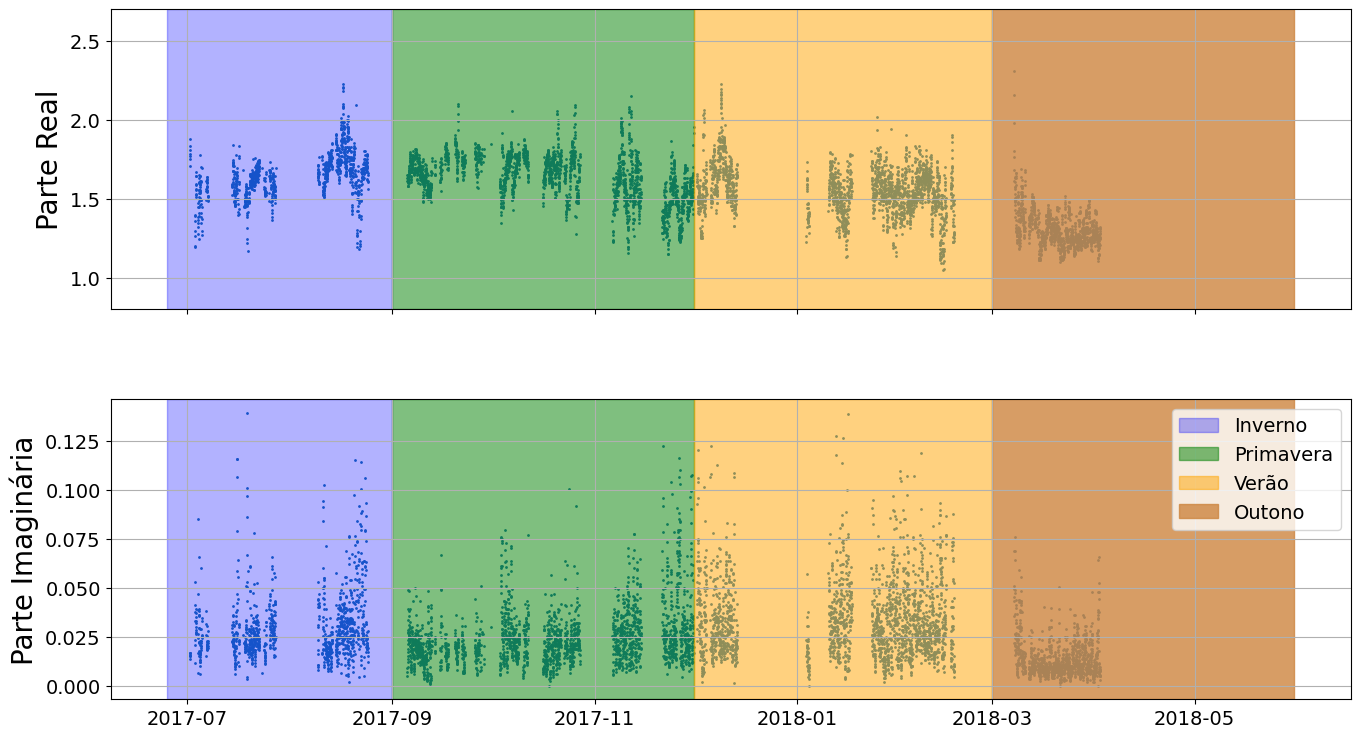

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10),sharex=True)
dados = [
    (smps_intersec.index, real, 'Parte Real','Real'),
    (smps_intersec.index, imaginaria, 'Parte Imaginária','Imaginária'),
] 

# Loop para plotar os gráficos com períodos diferenciados por cor
for i, (ax, (x, y, ylabel, title)) in enumerate(zip(axes.ravel(), dados)):
    ax.scatter(x, y,s=1)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid()
    ax.axvspan(pd.to_datetime(start_inverno), pd.to_datetime(end_inverno), color='blue', alpha=0.3, label='Inverno')
    ax.axvspan(pd.to_datetime(start_primavera), pd.to_datetime(end_primavera), color='green', alpha=0.5, label='Primavera')
    ax.axvspan(pd.to_datetime(start_verao), pd.to_datetime(end_verao), color='orange', alpha=0.5, label='Verão')
    ax.axvspan(pd.to_datetime(start_outono), pd.to_datetime(end_outono), color='peru', alpha=0.8, label='Outono')

    # Adiciona a legenda apenas no primeiro gráfico
    if i != 0:
        ax.legend(fontsize=14)

# Ajuste dos labels no eixo x do último subplot
axes[-1].tick_params(axis='x', labelsize=14)
axes[0].set_ylim(0.8,2.7)
plt.subplots_adjust(hspace=0.3, top=0.8)

plt.show()

Precisei retirar valores negativos do MAAP

É interessante deixar claro que existem alguns canais do SMPS retornam concentrações nulas, isso parece acontencer principalmente para os maiores diâmetros

matriz de correlacao (spearman), CDM, histogramas

Adicionando esses valores ao dataset

In [16]:
smps_intersec['Real'] = real
smps_intersec['Imaginária'] = imaginaria
smps_intersec = smps_intersec[smps_intersec['Real']>1.0]

In [17]:
serietemporaldf = smps_intersec.copy()

serietemporaldf = serietemporaldf.drop(serietemporaldf.columns[2:-2], axis=1)
serietemporaldf.to_csv('SerieTemporalCampinas.csv')

## Ciclo Diurno médio

NAO EXISTEM DADOS DE PMF NO VERAO. Como tratar isso? Posso fazer duas análises. Uma com tudo e uma usando só a intersecção de dados que existem composição química.

In [18]:
smps_intersec_inverno = smps_intersec.loc[start_inverno:end_inverno]
smps_intersec_verao = smps_intersec.loc[start_verao:end_verao]

In [19]:
smps_intersec_media_1h = smps_intersec.resample('60min').mean()
smps_intersec_media_1h['hour'] = smps_intersec_media_1h.index.hour
# Agrupando por hora e calculando a média
cdm_smps_intersec = smps_intersec_media_1h.groupby('hour').mean()


smps_intersec_media_1h_inverno = smps_intersec_inverno.resample('60min').mean()
smps_intersec_media_1h_inverno['hour'] = smps_intersec_media_1h_inverno.index.hour
# Agrupando por hora e calculando a média
cdm_smps_intersec_inverno = smps_intersec_media_1h_inverno.groupby('hour').mean()

smps_intersec_media_1h_verao= smps_intersec_verao.resample('60min').mean()
smps_intersec_media_1h_verao['hour'] = smps_intersec_media_1h_verao.index.hour
# Agrupando por hora e calculando a média
cdm_smps_intersec_verao = smps_intersec_media_1h_verao.groupby('hour').mean()

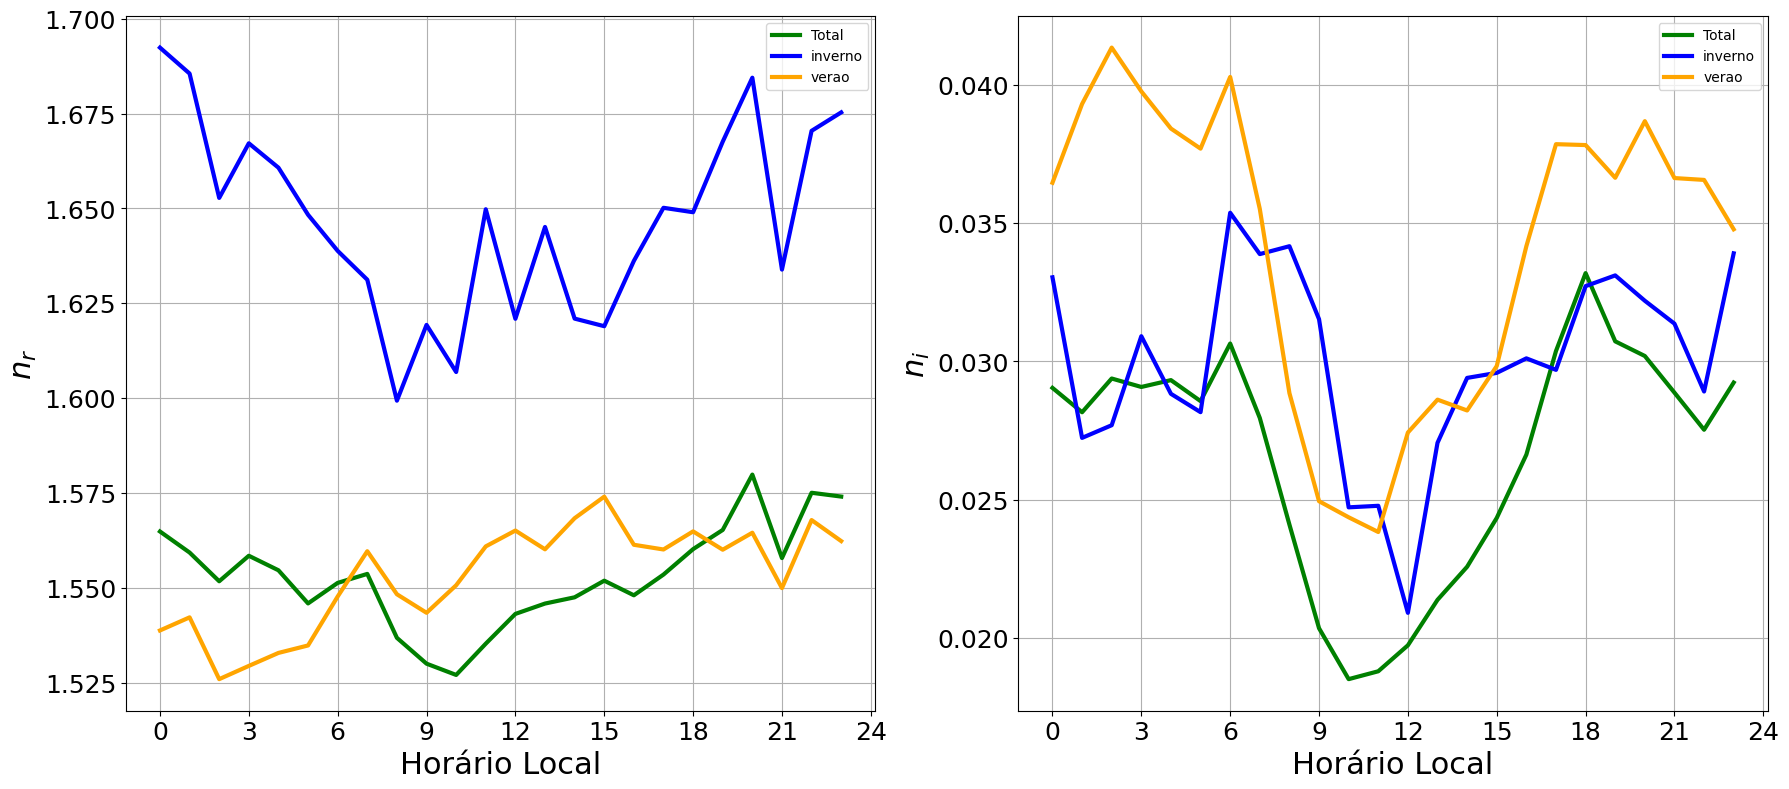

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Dados inverno e verao organizados para o loop
dados = [
    # Real
    (cdm_smps_intersec.index, cdm_smps_intersec['Real'],cdm_smps_intersec_inverno['Real'],cdm_smps_intersec_verao['Real'],
     '$n_r$', 'Diadema'),
    
    # Imaginária
    (cdm_smps_intersec.index, cdm_smps_intersec['Imaginária'],cdm_smps_intersec_inverno['Imaginária'],cdm_smps_intersec_verao['Imaginária'],
     '$n_i$', 'Diadema'),

]

# Loop para plotar os gráficos com períodos diferenciados por cor
for ax, (x, y,y_inverno, y_verao, ylabel, title) in zip(axes.flat, dados):
    ax.plot(x, y,linewidth = 3,color='green',label='Total')
    ax.plot(x, y_inverno,linewidth = 3,color='blue',label='inverno')
    ax.plot(x, y_verao,linewidth = 3,color='orange',label='verao')

    # Configurando fontes maiores para rótulos, títulos e legenda
    ax.set_ylabel(ylabel, fontsize=22)
    ax.set_xlabel('Horário Local', fontsize=22)
    ax.set_xticks(np.arange(0, 24.001, 3))
    ax.tick_params(axis='both', labelsize=18)  # Aumenta o tamanho dos ticks no eixo x e y
    #ax.legend(fontsize=16)  # Aumenta o tamanho da fonte da legenda
    ax.grid()
    ax.legend()

# Ajustar o layout para evitar sobreposição

plt.tight_layout()
plt.show()

## Composição Química

In [21]:
pmf = pd.read_csv('data/campinas/Campinas-2017_ACSM_Aerodyne_Level2_30min.csv', header=1,sep=';')

pmf = pmf.dropna(subset=[' Org Mean ugm-3'])#remove linhas com valores nulos na coluna
pmf = pmf[pmf[' Org Mean ugm-3']!=' NaN']


time = pd.to_datetime(pmf['Time(UTC)'], format='%d-%b-%Y %H:%M')

pmf['Time(UTC)'] = time
pmf.set_index('Time(UTC)', inplace=True)

pmf = pmf.drop([' ',' UnixTime(UTC)'], axis=1)


for column in pmf.columns:
   pmf['%s'%(column)] = pmf['%s'%(column)].astype(float)

pmf.index = pmf.index - timedelta(hours=3)
pmf.index.name = 'Time(UTC) - 3'

In [22]:
indices_comuns = smps_intersec.index.intersection(pmf.index)
smps_intersec = smps_intersec.loc[indices_comuns]
maap_intersec  = maap_intersec.loc[indices_comuns]
nefe_intersec  = nefe_intersec.loc[indices_comuns]
pmf_intersec  = pmf.loc[indices_comuns]
indices_comuns = smps_intersec.index.intersection(aet.index)
aet_intersec  = aet.loc[indices_comuns]

In [23]:
indices_comuns_aux = pmf.index.intersection(maap.index)
pmf  = pmf.loc[indices_comuns_aux]
maap_aux = maap.loc[indices_comuns_aux]
pmf[' BC637 Mean (ug.m-3)'] = maap_aux[' BC637 Mean (ug.m-3)'].values

In [24]:

pmf_intersec[' BC637 Mean (ug.m-3)'] = maap_intersec[' BC637 Mean (ug.m-3)'].values

### Ciclo diurno médio só para o período de composição química

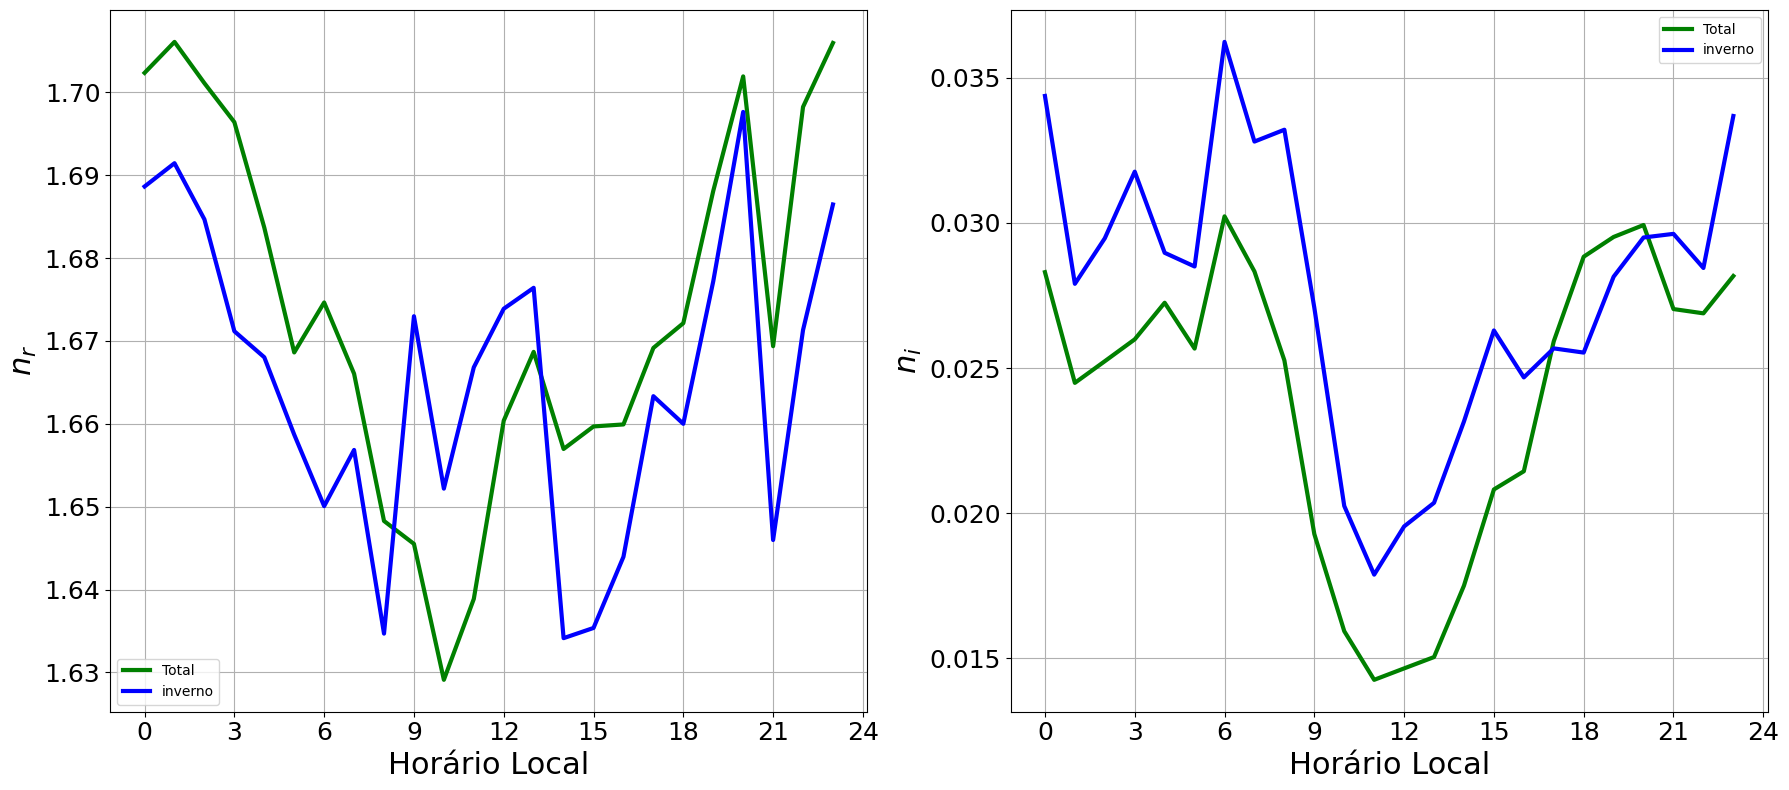

In [25]:
smps_intersec_inverno = smps_intersec.loc[start_inverno:end_inverno]


smps_intersec_media_1h = smps_intersec.resample('60min').mean()
smps_intersec_media_1h['hour'] = smps_intersec_media_1h.index.hour
# Agrupando por hora e calculando a média
cdm_smps_intersec = smps_intersec_media_1h.groupby('hour').mean()


smps_intersec_media_1h_inverno = smps_intersec_inverno.resample('60min').mean()
smps_intersec_media_1h_inverno['hour'] = smps_intersec_media_1h_inverno.index.hour
# Agrupando por hora e calculando a média
cdm_smps_intersec_inverno = smps_intersec_media_1h_inverno.groupby('hour').mean()



fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Dados inverno e verao organizados para o loop
dados = [
    # Real
    (cdm_smps_intersec.index, cdm_smps_intersec['Real'],cdm_smps_intersec_inverno['Real'],
     '$n_r$', 'Diadema'),
    
    # Imaginária
    (cdm_smps_intersec.index, cdm_smps_intersec['Imaginária'],cdm_smps_intersec_inverno['Imaginária'],
     '$n_i$', 'Diadema'),

]

# Loop para plotar os gráficos com períodos diferenciados por cor
for ax, (x, y,y_inverno, ylabel, title) in zip(axes.flat, dados):
    ax.plot(x, y,linewidth = 3,color='green',label='Total')
    ax.plot(x, y_inverno,linewidth = 3,color='blue',label='inverno')

    # Configurando fontes maiores para rótulos, títulos e legenda
    ax.set_ylabel(ylabel, fontsize=22)
    ax.set_xlabel('Horário Local', fontsize=22)
    ax.set_xticks(np.arange(0, 24.001, 3))
    ax.tick_params(axis='both', labelsize=18)  # Aumenta o tamanho dos ticks no eixo x e y
    #ax.legend(fontsize=16)  # Aumenta o tamanho da fonte da legenda
    ax.grid()
    ax.legend()

# Ajustar o layout para evitar sobreposição

plt.tight_layout()
plt.show()

Lembrando que o período "Total" não é mais o ano inteiro e sim o período que temos dados de composição química (Julho a Novembro).

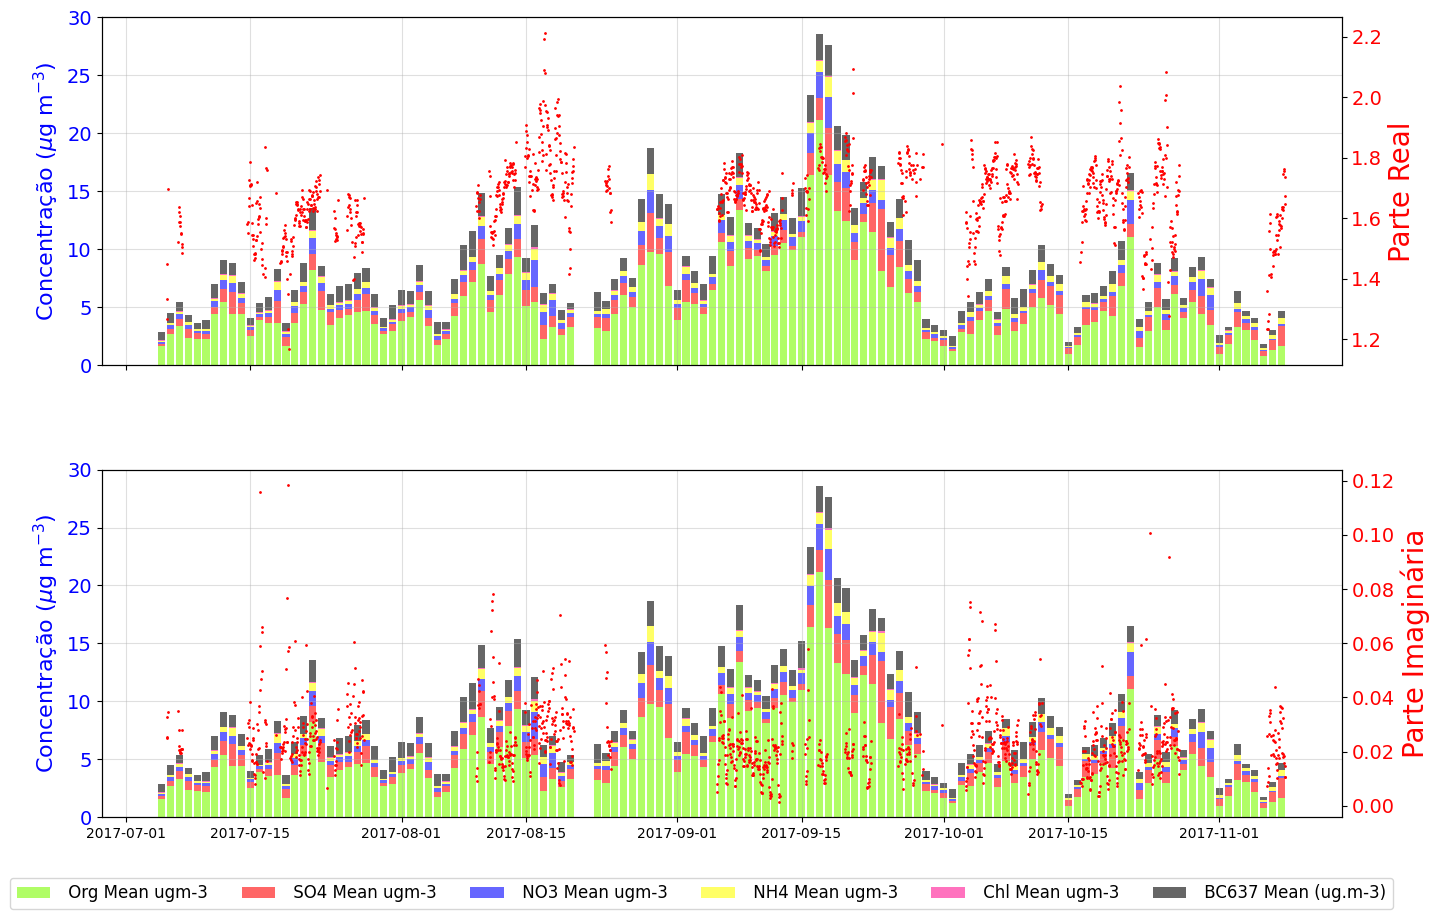

In [26]:
# --- Cores fixas para cada componente do PMF ---
cores_pmf = {
' BC637 Mean (ug.m-3)': 'k',
    ' Org Mean ugm-3': 'lawngreen',   # azul claro
    ' SO4 Mean ugm-3': 'red',   # laranja suave
    ' NO3 Mean ugm-3': 'blue',   # verde claro
    ' NH4 Mean ugm-3': 'yellow',   # rosa
    ' Chl Mean ugm-3': 'deeppink',
    
}

# --- Cria figura ---
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Dados usados nos dois subplots
dados = [
    (smps_intersec_media_1h.index, smps_intersec_media_1h['Real'],       'Parte Real',       'Real'),
    (smps_intersec_media_1h.index, smps_intersec_media_1h['Imaginária'], 'Parte Imaginária', 'Imaginária'),
]

# === Loop principal para os dois gráficos ===
for i, (ax, (x, y, ylabel, title)) in enumerate(zip(axes.ravel(), dados)):

    # Resample diário
    pmf_plot = pmf.resample('1440min').mean()

    # Limite comum das barras
    pmf_total = pmf_plot.sum(axis=1)
    pmf_max = pmf_total.max()

    # Segundo eixo para o scatter
    ax2 = ax.twinx()

    # --- Barras empilhadas do PMF ---
    bottom = np.zeros(len(pmf_plot))

    for col in pmf_plot.columns:
        ax.bar(
            pmf_plot.index,
            pmf_plot[col],
            bottom=bottom,
            label=col,
            color=cores_pmf[col],  # cores fixas aqui
            alpha=0.6,
            zorder=1
        )
        bottom += pmf_plot[col].values

    # Eixo da concentração (PMF)
    ax.set_ylabel('Concentração ($\\mu$g m$^{-3}$)', fontsize=16, color='blue')
    ax.tick_params(axis='y', labelcolor='blue', labelsize=14)
    ax.grid(alpha=0.4)
    ax.set_ylim(0, pmf_max * 1.05)

    # --- Scatter (SMPS) ---
    ax2.scatter(x, y, s=1, color='red', label=ylabel, zorder=2)
    ax2.set_ylabel(ylabel, fontsize=20, color='red')
    ax2.tick_params(axis='y', labelcolor='red', labelsize=14)
    ax2.tick_params(axis='x', labelsize=14)

# === Legenda combinada ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=len(pmf_plot.columns),
    fontsize=12,
    frameon=True
)

# === Ajustes finais ===
plt.subplots_adjust(hspace=0.3, bottom=0.08)
plt.show()

In [27]:
df_total = pd.concat([smps_intersec, maap_intersec, nefe_intersec,pmf_intersec], axis=1)
df_total = df_total[['scat637 Mean (Mm-1)','SAE',' Abs637 Mean (Mm-1)','Real','Imaginária',
                     ' Mean diameter Mean (nm)',' Total concentration Mean (cm-3)',' Org Mean ugm-3', ' SO4 Mean ugm-3',
       ' NO3 Mean ugm-3', ' NH4 Mean ugm-3', ' Chl Mean ugm-3']]

<AxesSubplot: >

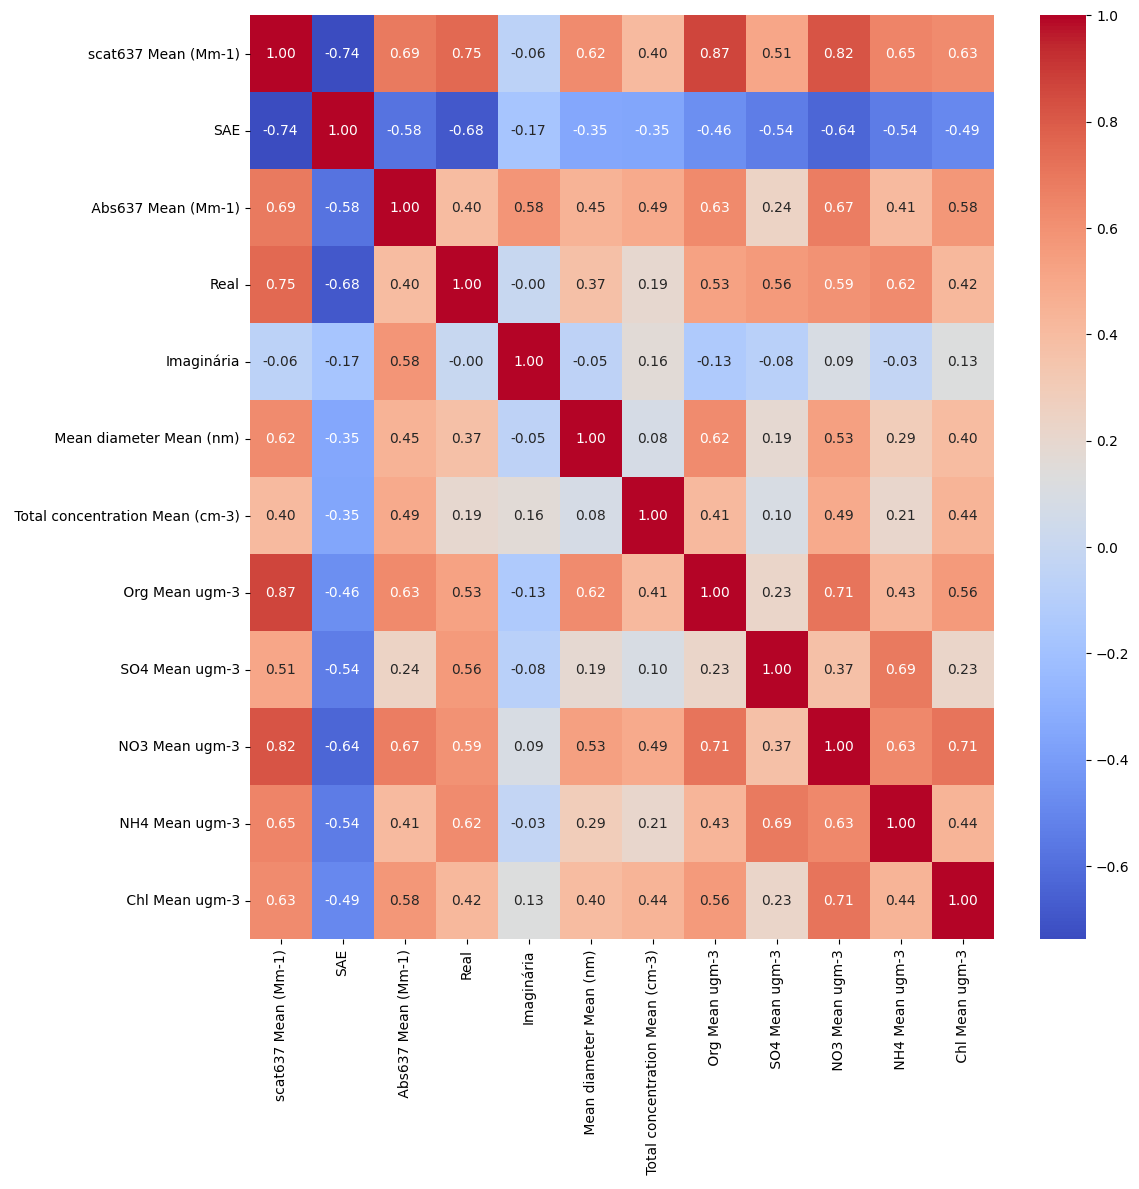

In [28]:
import seaborn as sns
plt.figure(figsize=(12, 12))
sns.heatmap(df_total.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f")

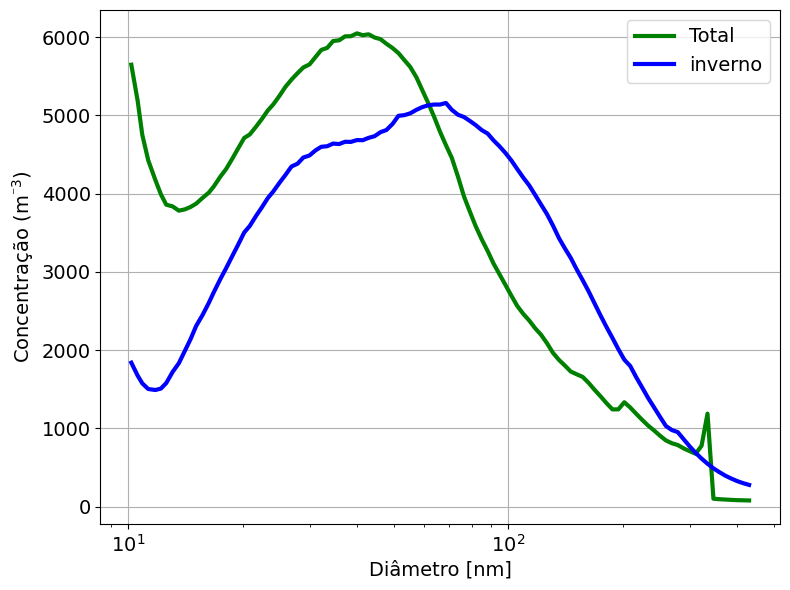

In [29]:
# Criar subplots com uma matriz 2x2
fig = plt.subplots(figsize=(8, 6))

# Dados inverno e verao organizados para o loop
dados = [
    # inverno
    (smps_intersec_verao, smps_intersec_inverno),
]

# Loop para plotar os gráficos com períodos diferenciados por cor
for (df_verao,df_inverno) in (dados):
    
    df_auxiliar_verao = df_verao.drop(columns=['Real','Imaginária','index',' UnixTime(UTC)',' Total concentration Mean (cm-3)',' Total volume Mean (um3.cm-3)', ' Mean diameter Mean (nm)'])
    df_auxiliar_verao = pd.DataFrame(df_auxiliar_verao.mean()).T

    df_auxiliar_inverno= df_inverno.drop(columns=['Real','Imaginária','index',' UnixTime(UTC)',' Total concentration Mean (cm-3)',' Total volume Mean (um3.cm-3)', ' Mean diameter Mean (nm)'])
    df_auxiliar_inverno = pd.DataFrame(df_auxiliar_inverno.mean()).T

    sizeDistributionDiameterBins = df_auxiliar_verao.columns.tolist()
    sizeDistributionDiameterBins = np.array([float(x) for x in sizeDistributionDiameterBins])



    plt.plot(sizeDistributionDiameterBins, df_auxiliar_verao.iloc[0],linewidth = 3,color='green',label='Total')
    plt.plot(sizeDistributionDiameterBins, df_auxiliar_inverno.iloc[0],linewidth = 3,color='blue',label='inverno')
    # Configurando fontes maiores para rótulos, títulos e legenda
    plt.ylabel('Concentração (m$^{⁻3}$)', fontsize=14)
    plt.xlabel('Diâmetro [nm]', fontsize=14)
    plt.tick_params(axis='both', labelsize=14)  # Aumenta o tamanho dos ticks no eixo x e y
    #ax.legend(fontsize=16)  # Aumenta o tamanho da fonte da legenda
    plt.grid()
    plt.legend(fontsize=14)
    plt.xscale('log')
# Ajustar o layout para evitar sobreposição

plt.tight_layout()
plt.show()

### Pizzas

In [30]:
maap_inverno = maap_intersec.loc[start_inverno:end_inverno]
concentracoes_inverno = pmf_intersec.loc[start_inverno:end_inverno]
concentracoes_inverno['BC637 Mean (ug.m-3)'] = maap_inverno[' BC637 Mean (ug.m-3)'].values
 

concentracoes_total = pmf_intersec.copy()
concentracoes_total ['BC637 Mean (ug.m-3)'] = maap_intersec[' BC637 Mean (ug.m-3)'].values

/tmp/ipykernel_11335/830281368.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  concentracoes_inverno['BC637 Mean (ug.m-3)'] = maap_inverno[' BC637 Mean (ug.m-3)'].values


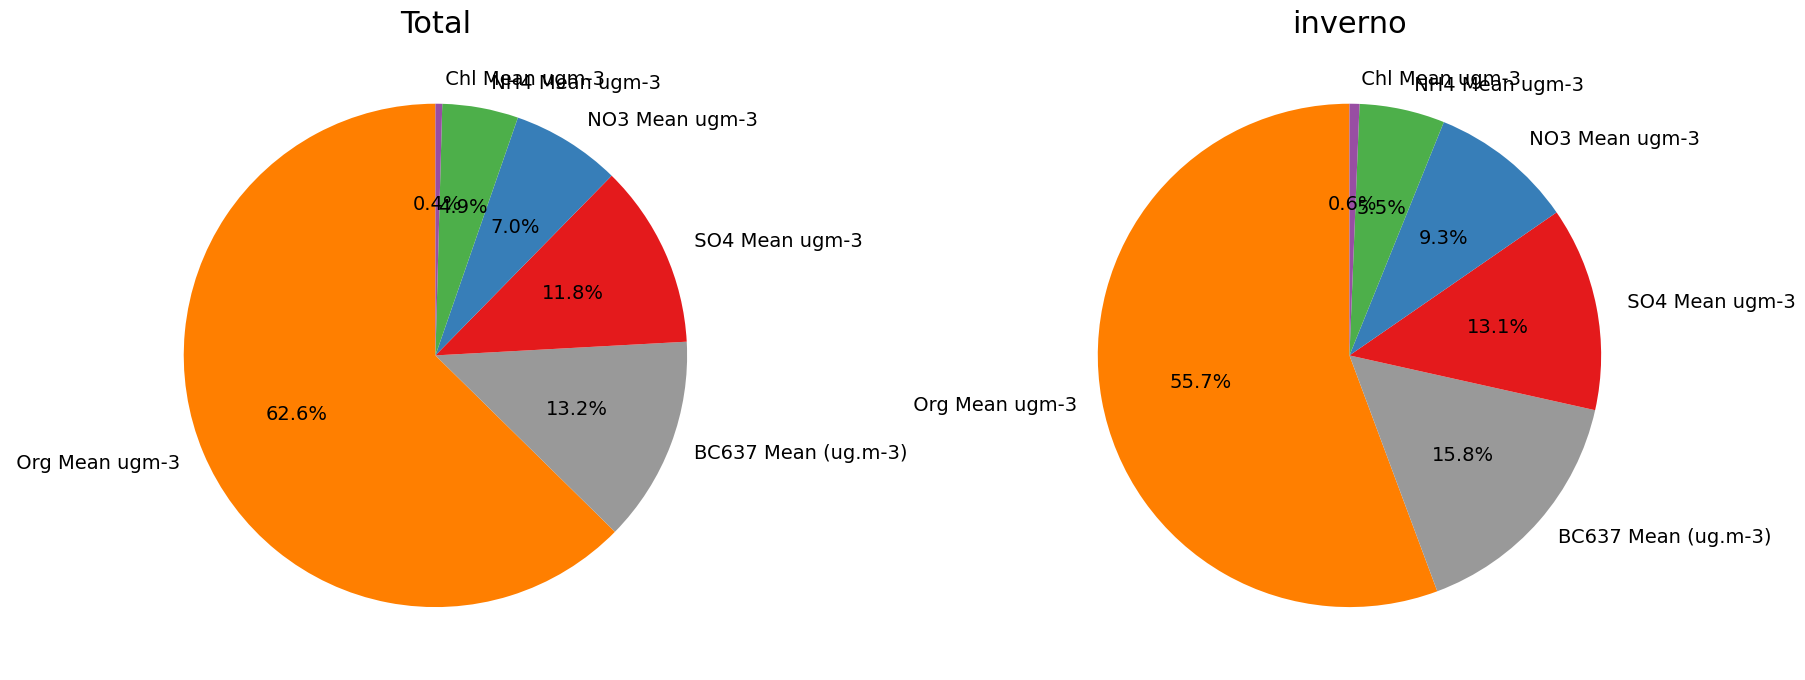

In [31]:
# Criar subplots com uma matriz 1x2
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Dicionário de cores fixas por componente
cores_por_componente = {
    ' SO4 Mean ugm-3': '#e41a1c',
    ' NO3 Mean ugm-3': '#377eb8',
    ' NH4 Mean ugm-3': '#4daf4a',
    ' Chl Mean ugm-3': '#984ea3',
    'ooa': '#ff7f00',
    'bboa': '#ffff33',
    'hoa55': '#a65628',
    'hoa57': '#f781bf',
    'BC637 Mean (ug.m-3)': '#999999',
    ' Org Mean ugm-3': '#ff7f00'
}

# Dados inverno e estiagem organizados para o loop
dados = [
    (concentracoes_total, 'Total'),
    (concentracoes_inverno, 'inverno'),
]

# Loop para plotar os gráficos com períodos diferenciados
for ax, (df, title) in zip(axes.flat, dados):
    df = df[[' Org Mean ugm-3', ' SO4 Mean ugm-3',
             ' NO3 Mean ugm-3', ' NH4 Mean ugm-3', ' Chl Mean ugm-3',
             'BC637 Mean (ug.m-3)']]
    media_colunas = df.mean().sort_values(ascending=False)

    # Selecionar as cores conforme a ordem das colunas
    cores = [cores_por_componente[col] for col in media_colunas.index]

    # Criar gráfico de pizza
    wedges, texts, autotexts = ax.pie(
        media_colunas.values,
        labels=media_colunas.index,
        colors=cores,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 14}
    )

    # Configurações visuais
    ax.set_title(title, fontsize=22)
    for text in texts + autotexts:
        text.set_fontsize(14)

# Ajustar o layout
plt.tight_layout()
plt.show()

### Extras

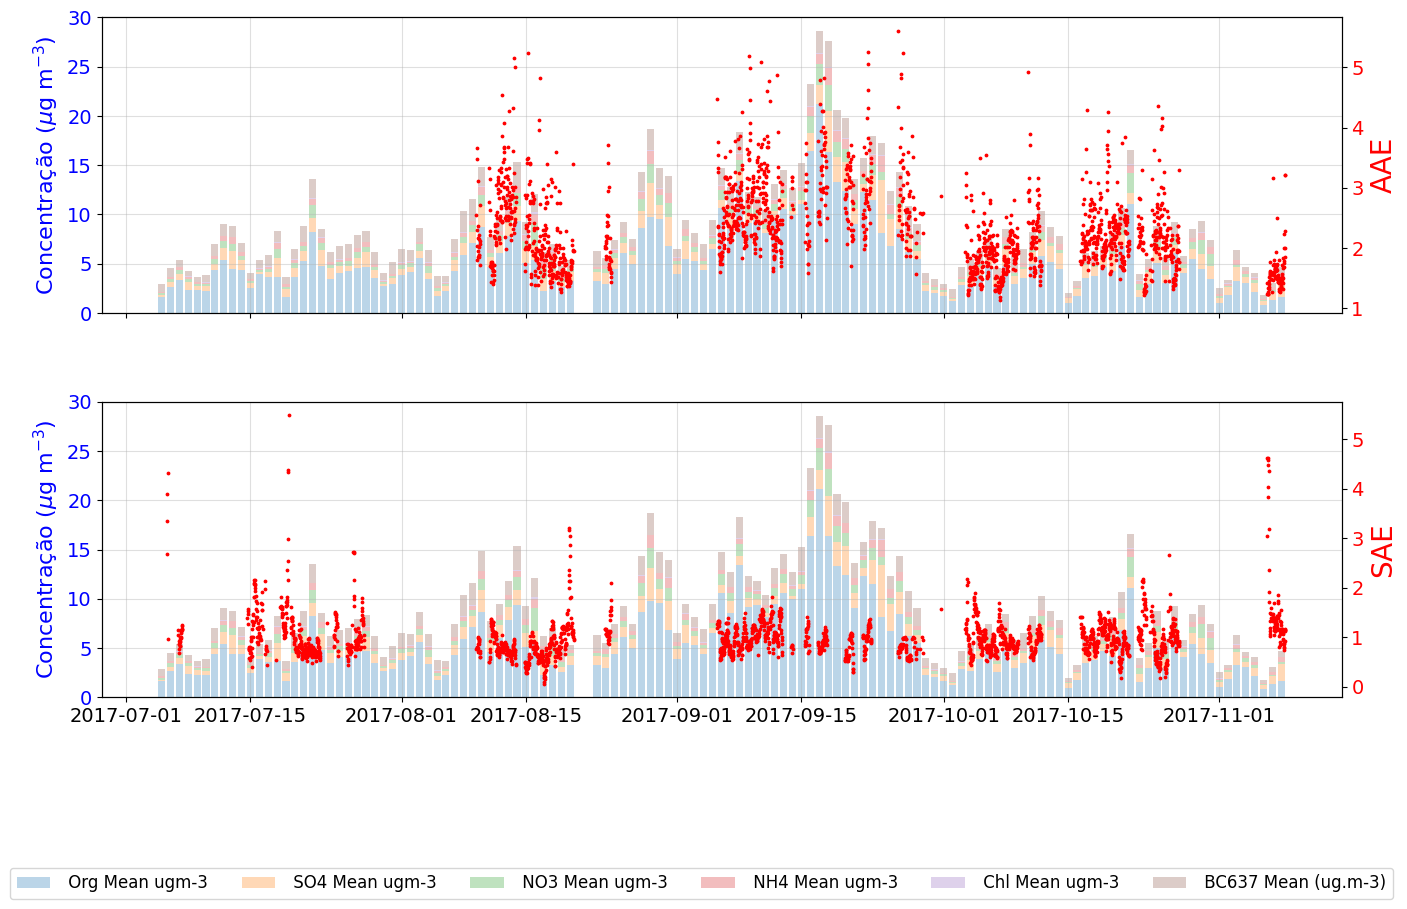

In [32]:

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

dados = [
    (aet_intersec.index, aet_intersec[' AAE Mean (adim)'], 'AAE', 'AAE'),
    (nefe_intersec.index, nefe_intersec['SAE'], 'SAE', 'SAE'),
] 

# === Loop principal ===
for i, (ax, (x, y, ylabel, title)) in enumerate(zip(axes.ravel(), dados)):
    pmf_plot = pmf.resample('1440min').mean()
    
    # === Calcula o limite máximo total do PMF ===
    pmf_total = pmf_plot.sum(axis=1)
    pmf_max = pmf_total.max()

    # Cria o segundo eixo y (vermelho)
    ax2 = ax.twinx()
    
    # --- Barras empilhadas do PMF ---
    bottom = np.zeros(len(pmf_plot))
    for col in pmf_plot.columns:
        ax.bar(pmf_plot.index, pmf_plot[col], bottom=bottom, label=col, alpha=0.3, zorder=1)
        bottom += pmf_plot[col].values

    ax.set_ylabel('Concentração ($\mu$g m$^{-3}$)', fontsize=16, color='blue')
    ax.tick_params(axis='y', labelcolor='blue', labelsize=14)
    ax.grid(alpha=0.4)
    ax.set_ylim(0, pmf_max * 1.05)  # mesmo limite nos dois gráficos
    
    # --- Scatter (SMPS) ---
    ax2.scatter(x, y, s=3, color='red', label=ylabel, zorder=2)
    ax2.set_ylabel(ylabel, fontsize=20, color='red')
    ax2.tick_params(axis='y', labelcolor='red', labelsize=14)
    ax2.tick_params(axis='x', labelsize=14)


# === Legenda combinada ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.01),
           ncol=len(pmf_plot.columns) + 3, 
           fontsize=12, 
           frameon=True)

# === Ajustes finais ===
axes[-1].tick_params(axis='x', labelsize=14)
sum(pmf_plot.iloc[0])
plt.subplots_adjust(hspace=0.3, bottom=0.2)
plt.show()


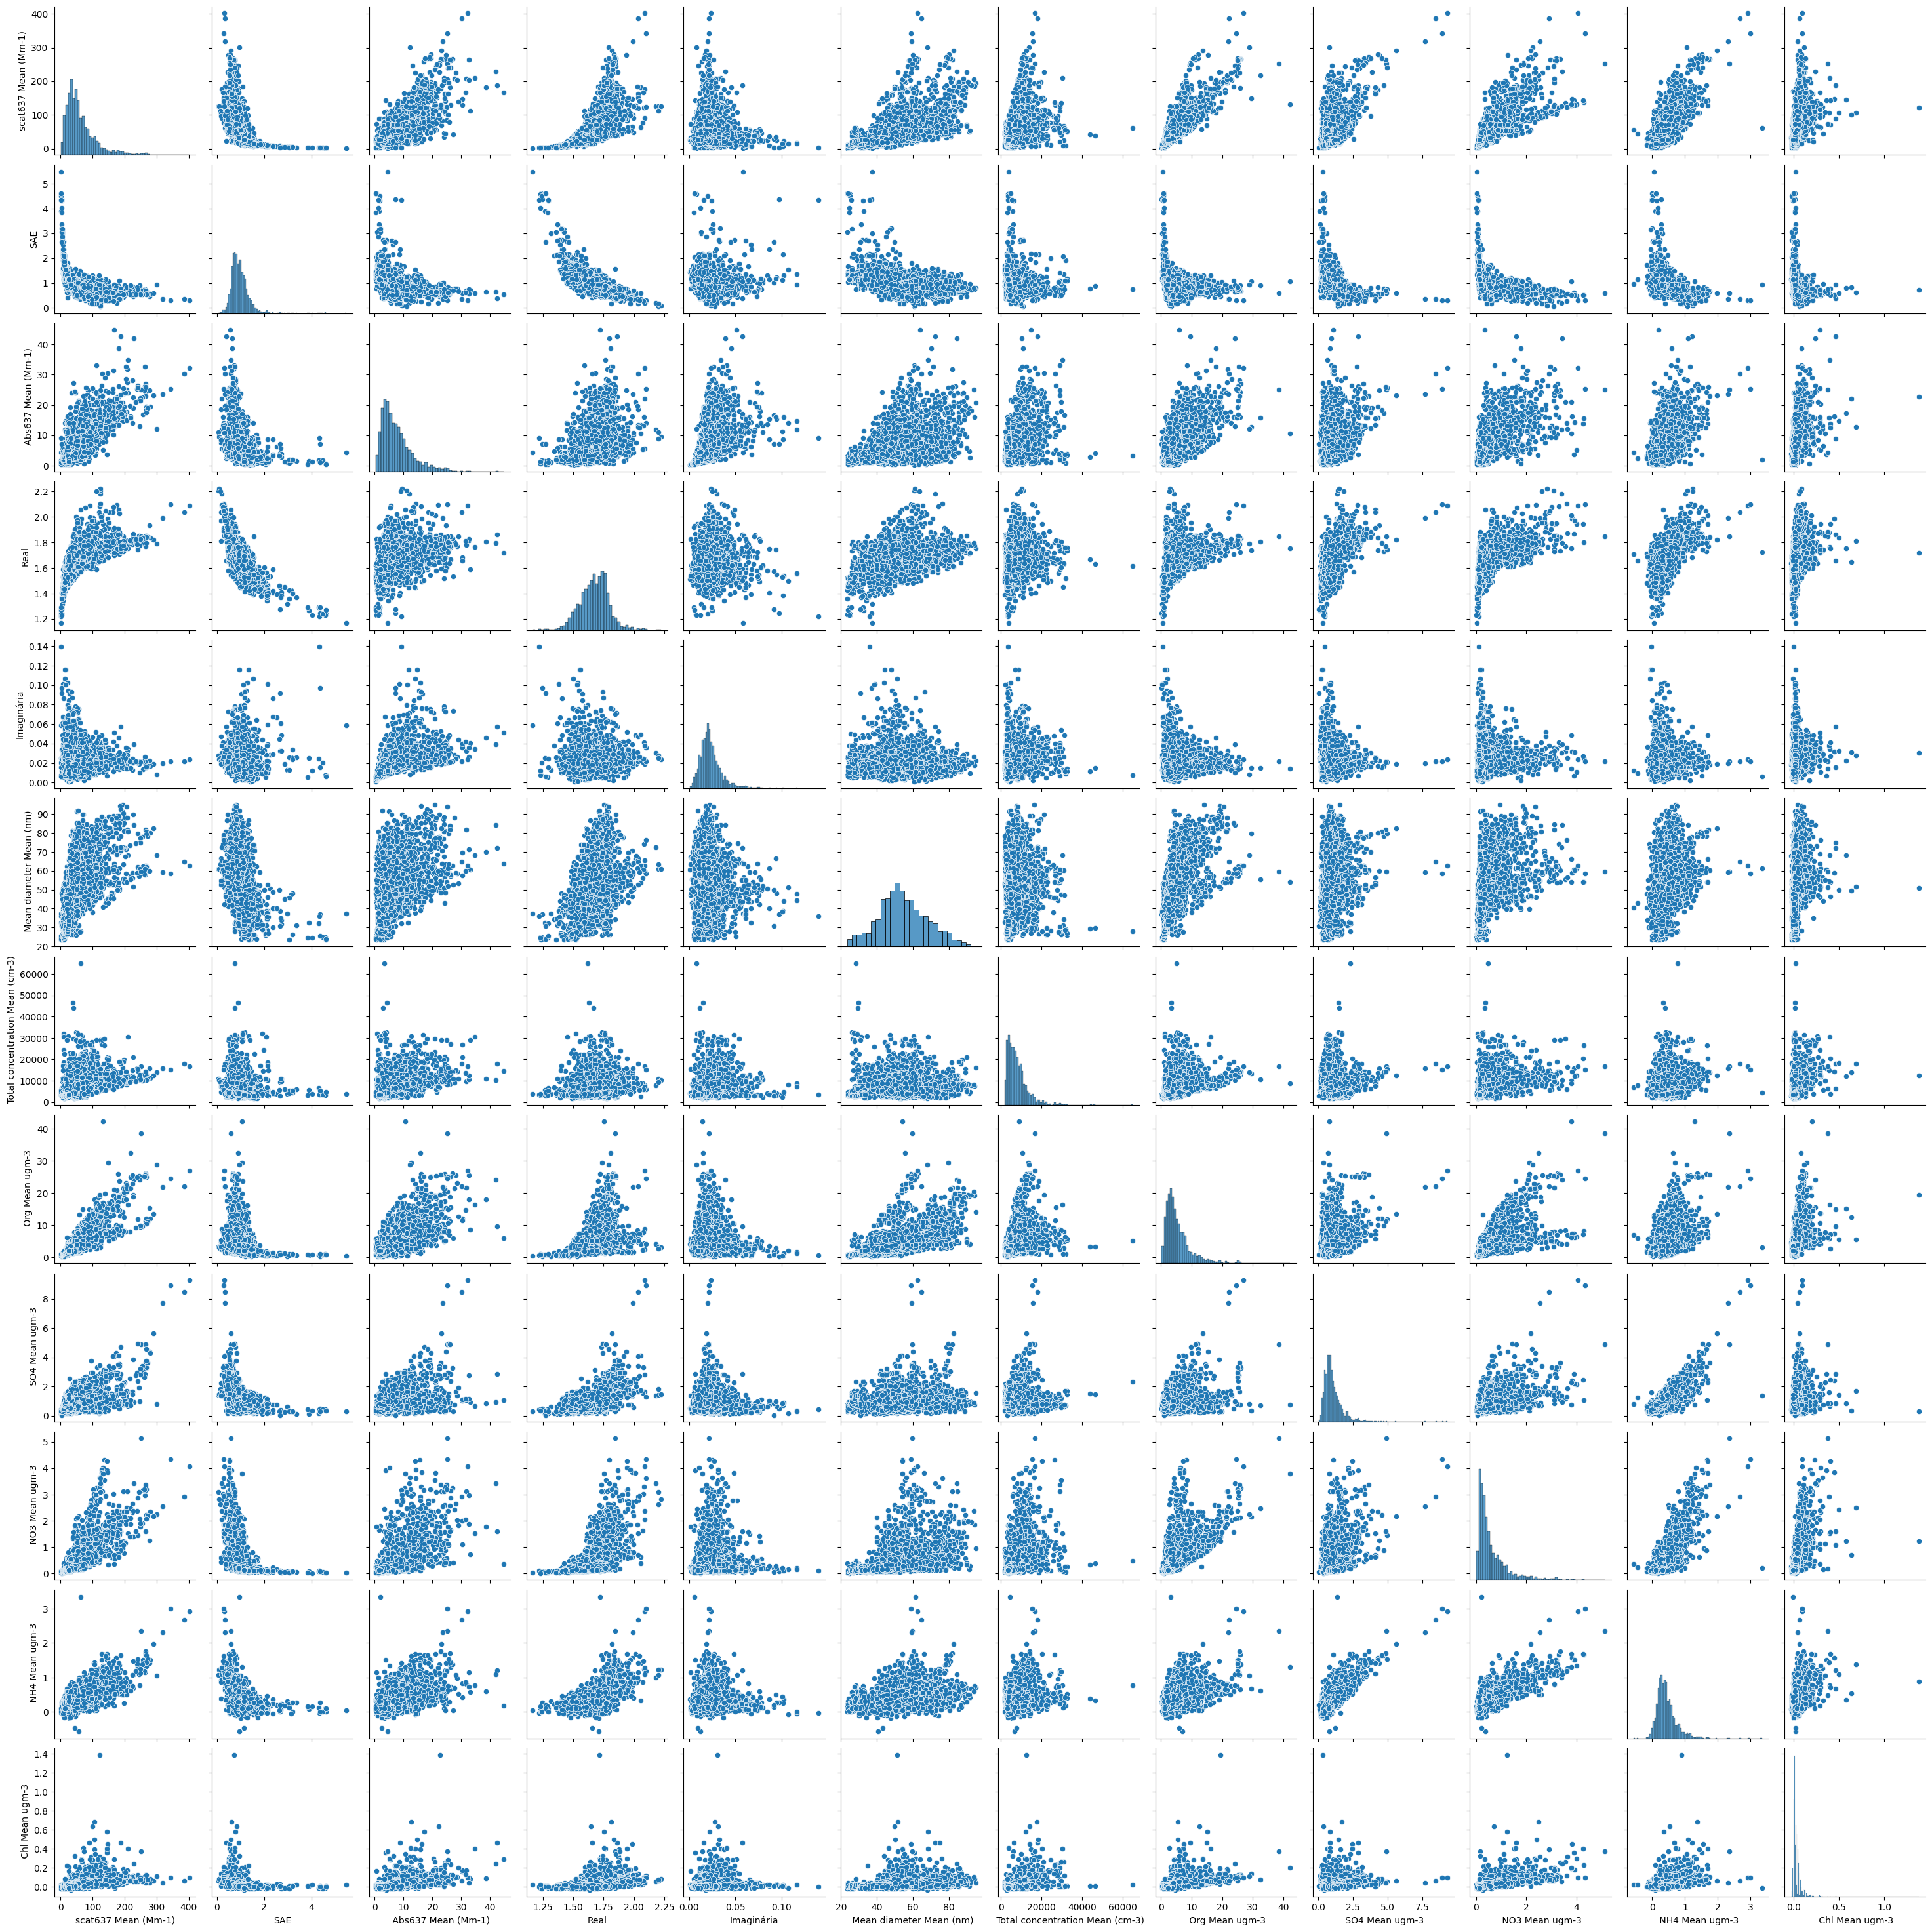

In [33]:
sns.pairplot(df_total)

In [34]:
len(smps_intersec)

2368